# Tasks 2–4 (Tony) — Sydney - Parramatta

This notebook covers:
- **Task 2** — `nearbyPOI` function, SA2 loop, store POI data in Pandas/GeoPandas DataFrame + PostGIS table, verify access.
- **Task 3** — well-resourced score per SA2.
- **Task 4** — score distribution + map overlay.

## Task 2.1 — `nearbyPOI(...)` function

In [2]:
import requests
import pandas as pd
import geopandas as gpd
from io import BytesIO
from shapely.geometry import Point

POI_URL = "https://maps.six.nsw.gov.au/arcgis/rest/services/public/NSW_POI/MapServer/0/query"

def nearbyPOI(min_lon, min_lat, max_lon, max_lat):
    """Return all NSW POIs (attributes + geometry) within the given bounding box."""
    pois, offset = [], 0
    while True:
        params = {
            "where":             "1=1",
            "geometry":          f"{min_lon},{min_lat},{max_lon},{max_lat}",
            "geometryType":      "esriGeometryEnvelope",
            "inSR":              "4326",
            "outFields":         "objectid,topoid,poigroup,poitype,poiname,poilabel,poilabeltype,urbanity,startdate,enddate",
            "returnGeometry":    "true",
            "resultOffset":      offset,
            "resultRecordCount": 1000,
            "f":                 "json",
        }
        r = requests.get(POI_URL, params=params)
        features = r.json()["features"]
        for f in features:
            row = f["attributes"]
            row["longitude"] = f["geometry"]["x"]
            row["latitude"]  = f["geometry"]["y"]
            pois.append(row)
        if len(features) < 1000:
            break
        offset += 1000
    return pd.DataFrame(pois)


## Task 2.2 — Load SA2 boundaries for Sydney - Parramatta and verify with Shapely

In [3]:
# Fetch SA2 polygons from the ABS REST endpoint, filter to Sydney - Parramatta
abs_url = "https://geo.abs.gov.au/arcgis/rest/services/ASGS2021/SA2/MapServer/0/query"
params = {
    "where":          "SA4_NAME_2021 = 'Sydney - Parramatta'",
    "outFields":      "SA2_CODE_2021,SA2_NAME_2021,SA3_NAME_2021,SA4_NAME_2021",
    "returnGeometry": "true",
    "outSR":          "4326",
    "f":              "geojson",
}
parra = gpd.read_file(BytesIO(requests.get(abs_url, params=params).content))
print(f"{len(parra)} SA2s in Sydney - Parramatta")

# Shapely verification: each SA2 polygon is within the SA4 envelope
sa4_envelope = parra.unary_union.convex_hull
print(f"All SA2s within SA4 envelope? {parra.geometry.within(sa4_envelope).all()}")


34 SA2s in Sydney - Parramatta
All SA2s within SA4 envelope? True


/var/folders/d0/nrx61kw90qscpg9sdmvy_fg00000gn/T/ipykernel_94063/128457090.py:14: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  sa4_envelope = parra.unary_union.convex_hull


## Task 2.3 — Loop through each SA2, call `nearbyPOI()` per SA2 bbox

In [4]:
# For every SA2 in Sydney - Parramatta: compute its bbox, fetch POIs, filter to inside-polygon
all_rows = []

for _, sa2_row in parra.iterrows():
    sa2_code = sa2_row["sa2_code_2021"]
    sa2_name = sa2_row["sa2_name_2021"]
    polygon  = sa2_row["geometry"]

    pois = nearbyPOI(*polygon.bounds)
    if len(pois) == 0:
        print(f"{sa2_name}: 0 POIs")
        continue

    inside_mask = pois.apply(
        lambda r: polygon.contains(Point(r["longitude"], r["latitude"])),
        axis=1
    )
    inside = pois[inside_mask].copy()
    inside["sa2_code"] = sa2_code
    inside["sa2_name"] = sa2_name
    print(f"{sa2_name}: {len(inside)} POIs")
    all_rows.append(inside)

# All POIs with attributes + geometry, stored in a GeoPandas dataframe
sa2swithpois = gpd.GeoDataFrame(
    pd.concat(all_rows, ignore_index=True),
    geometry=gpd.points_from_xy(
        pd.concat(all_rows, ignore_index=True)["longitude"],
        pd.concat(all_rows, ignore_index=True)["latitude"],
    ),
    crs="EPSG:4326",
)
print(f"\nTotal POIs in Sydney - Parramatta: {len(sa2swithpois)}")
sa2swithpois.head()


Rookwood Cemetery: 9 POIs
Auburn - Central: 68 POIs
Auburn - North: 21 POIs
Auburn - South: 22 POIs
Berala: 20 POIs
Lidcombe: 83 POIs
Regents Park: 32 POIs
Silverwater - Newington: 37 POIs
Wentworth Point - Sydney Olympic Park: 94 POIs
Ermington - Rydalmere: 118 POIs
Oatlands - Dundas Valley: 82 POIs
Carlingford - East: 48 POIs
Carlingford - West: 61 POIs
Chester Hill - Sefton: 71 POIs
Fairfield - East: 79 POIs
Granville - Clyde: 105 POIs
Guildford - South Granville: 84 POIs
Guildford West - Merrylands West: 96 POIs
Smithfield Industrial: 11 POIs
Yennora Industrial: 3 POIs
Greystanes - South: 50 POIs
Merrylands - Holroyd: 112 POIs
Pemulwuy - Greystanes (North): 63 POIs
South Wentworthville: 16 POIs
North Parramatta: 132 POIs
North Rocks: 37 POIs
Northmead: 97 POIs
Toongabbie - Constitution Hill: 82 POIs
Winston Hills: 66 POIs
Pendle Hill - Girraween: 50 POIs
Wentworthville - Westmead: 74 POIs
Parramatta - North: 94 POIs
Parramatta - South: 21 POIs
Rosehill - Harris Park: 48 POIs

Total

,objectid,topoid,poigroup,poitype,poiname,poilabel,poilabeltype,urbanity,startdate,enddate,longitude,latitude,sa2_code,sa2_name,geometry
0,1149,500190037,1,Cemetery,ROOKWOOD CEMETERY,ROOKWOOD CEMETERY,NAMED,U,1285588392000,32503680000000,151.053588,-33.868984,125011475,Rookwood Cemetery,POINT (151.05359 -33.86898)
1,2903,500319085,1,Cemetery,ROOKWOOD CEMETERY,ROOKWOOD CEMETERY,NAMED,U,1285588392000,32503680000000,151.054700,-33.876471,125011475,Rookwood Cemetery,POINT (151.0547 -33.87647)
2,27012,504379674,1,Crematorium,ROOKWOOD MEMORIAL GARDENS AND CREMATORIUM,ROOKWOOD MEMORIAL GARDENS AND CREMATORIUM,NAMED,U,1416303817000,32503680000000,151.059782,-33.877265,125011475,Rookwood Cemetery,POINT (151.05978 -33.87727)
3,53271,511753745,8,Suburb,ROOKWOOD,ROOKWOOD,NAMED,U,1285588392000,32503680000000,151.054542,-33.878671,125011475,Rookwood Cemetery,POINT (151.05454 -33.87867)
4,133745,517589482,3,Historic Site,ROOKWOOD CEMETERY AND NECROPOLIS,ROOKWOOD CEMETERY AND NECROPOLIS,NAMED,U,1416303817000,32503680000000,151.051350,-33.869457,125011475,Rookwood Cemetery,POINT (151.05135 -33.86946)


Field meanings for `objectid`, `topoid`, `poigroup`, `poitype`, `poiname`, `urbanity`, etc. are documented in the [NSW Topographic Data Dictionary](https://www.spatial.nsw.gov.au).

## Task 2.4 — PostgreSQL + PostGIS connection (Python DB-API)

In [5]:
import psycopg2

# TODO: update connection details to your own Postgres
conn = psycopg2.connect(
    host="localhost", port=5434,
    database="postgres", user="postgres", password="0801",
)
cur = conn.cursor()
cur.execute("SELECT PostGIS_version();")
print("PostGIS:", cur.fetchone()[0])


PostGIS: 3.6 USE_GEOS=1 USE_PROJ=1 USE_STATS=1


## Task 2.5 — Ingest `sa2swithpois` into a PostGIS table

In [6]:
from psycopg2.extras import execute_values

# Drop existing table and recreate with the right schema
cur.execute("DROP TABLE IF EXISTS sa2swithpois;")
cur.execute("""
CREATE TABLE sa2swithpois (
    objectid     BIGINT,
    topoid       BIGINT,
    poigroup     INTEGER,
    poitype      TEXT,
    poiname      TEXT,
    poilabel     TEXT,
    poilabeltype TEXT,
    urbanity     VARCHAR(2),
    startdate    BIGINT,
    enddate      BIGINT,
    sa2_code     VARCHAR(9),
    sa2_name     TEXT,
    geometry     geometry(Point, 4326)
);
""")
conn.commit()

# Build the list of tuples; last two values become the geometry via ST_MakePoint
rows = []
for _, r in sa2swithpois.iterrows():
    rows.append((
        int(r['objectid'])  if pd.notna(r['objectid']) else None,
        int(r['topoid'])    if pd.notna(r['topoid'])   else None,
        int(r['poigroup'])  if pd.notna(r['poigroup']) else None,
        r['poitype']        if pd.notna(r['poitype'])  else None,
        r['poiname']        if pd.notna(r['poiname'])  else None,
        r['poilabel']       if pd.notna(r['poilabel']) else None,
        r['poilabeltype']   if pd.notna(r['poilabeltype']) else None,
        r['urbanity']       if pd.notna(r['urbanity']) else None,
        int(r['startdate']) if pd.notna(r['startdate']) else None,
        int(r['enddate'])   if pd.notna(r['enddate'])  else None,
        r['sa2_code'],
        r['sa2_name'],
        float(r['longitude']),
        float(r['latitude']),
    ))

execute_values(
    cur,
    """INSERT INTO sa2swithpois
       (objectid, topoid, poigroup, poitype, poiname, poilabel, poilabeltype,
        urbanity, startdate, enddate, sa2_code, sa2_name, geometry)
       VALUES %s""",
    rows,
    template="(%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, ST_SetSRID(ST_MakePoint(%s, %s), 4326))"
)
conn.commit()

cur.execute("SELECT COUNT(*) FROM sa2swithpois;")
print(f"Ingested {cur.fetchone()[0]} rows into PostGIS table 'sa2swithpois'.")


Ingested 2086 rows into PostGIS table 'sa2swithpois'.


## Task 2.6 — Access stored data (Python DB-API + PostGIS SQL)

In [7]:
# (a) Access via Python DB-API
sample = pd.read_sql("SELECT objectid, poiname, poitype, sa2_name FROM sa2swithpois LIMIT 5;", conn)
print("Python DB-API access:")
print(sample.to_string(index=False))


Python DB-API access:
 objectid                                   poiname       poitype          sa2_name
     1149                         ROOKWOOD CEMETERY      Cemetery Rookwood Cemetery
     2903                         ROOKWOOD CEMETERY      Cemetery Rookwood Cemetery
    27012 ROOKWOOD MEMORIAL GARDENS AND CREMATORIUM   Crematorium Rookwood Cemetery
    53271                                  ROOKWOOD        Suburb Rookwood Cemetery
   133745          ROOKWOOD CEMETERY AND NECROPOLIS Historic Site Rookwood Cemetery


/var/folders/d0/nrx61kw90qscpg9sdmvy_fg00000gn/T/ipykernel_94063/1861991072.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sample = pd.read_sql("SELECT objectid, poiname, poitype, sa2_name FROM sa2swithpois LIMIT 5;", conn)


In [8]:
# (b) Access via direct PostGIS SQL (using spatial functions)
counts = pd.read_sql("""
SELECT sa2_name, COUNT(*) AS poi_count, ST_AsText(ST_Centroid(ST_Collect(geometry))) AS centroid
FROM   sa2swithpois
GROUP  BY sa2_name
ORDER  BY poi_count DESC
LIMIT  10;
""", conn)
print("PostGIS SQL access (Top 10 SA2s):")
print(counts.to_string(index=False))


PostGIS SQL access (Top 10 SA2s):
                             sa2_name  poi_count                                      centroid
                     North Parramatta        132 POINT(151.00925866303365 -33.802724277562405)
                Ermington - Rydalmere        118   POINT(151.0519724465877 -33.81134867291761)
                 Merrylands - Holroyd        112  POINT(150.98444547272538 -33.83397575364498)
                    Granville - Clyde        105   POINT(151.01009359305806 -33.8349477475808)
                            Northmead         97 POINT(150.99091059992082 -33.796681770085925)
     Guildford West - Merrylands West         96 POINT(150.97008056321576 -33.845942597265854)
Wentworth Point - Sydney Olympic Park         94  POINT(151.0694138804177 -33.844906189899234)
                   Parramatta - North         94   POINT(151.0032163192679 -33.81472670085324)
          Guildford - South Granville         84   POINT(151.0019867223402 -33.85695683418515)
                

/var/folders/d0/nrx61kw90qscpg9sdmvy_fg00000gn/T/ipykernel_94063/1593763988.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  counts = pd.read_sql("""


## Task 3 — Well-resourced score per SA2

`Score = S(z_POI)` where `z_POI = (poi_count − μ) / σ` and `S(x) = 1 / (1 + e^(−x))`.

In [9]:
import numpy as np

# Count POIs per SA2
poi_counts = pd.read_sql("""
SELECT sa2_code, sa2_name, COUNT(*) AS poi_count
FROM   sa2swithpois
GROUP  BY sa2_code, sa2_name
ORDER  BY poi_count DESC;
""", conn)

mu = poi_counts['poi_count'].mean()
sd = poi_counts['poi_count'].std()
poi_counts['z_poi'] = (poi_counts['poi_count'] - mu) / sd
poi_counts['score'] = 1.0 / (1.0 + np.exp(-poi_counts['z_poi']))

print(f"Scored {len(poi_counts)} SA2s in Sydney - Parramatta")
print(f"Score range: {poi_counts['score'].min():.3f} – {poi_counts['score'].max():.3f}")
print(f"\nTop 5:");    print(poi_counts.head(5)[['sa2_name','poi_count','score']].to_string(index=False))
print(f"\nBottom 5:"); print(poi_counts.tail(5)[['sa2_name','poi_count','score']].to_string(index=False))


Scored 34 SA2s in Sydney - Parramatta
Score range: 0.157 – 0.885

Top 5:
             sa2_name  poi_count    score
     North Parramatta        132 0.884726
Ermington - Rydalmere        118 0.836732
 Merrylands - Holroyd        112 0.811690
    Granville - Clyde        105 0.778870
            Northmead         97 0.736590

Bottom 5:
             sa2_name  poi_count    score
               Berala         20 0.232738
 South Wentworthville         16 0.212770
Smithfield Industrial         11 0.189611
    Rookwood Cemetery          9 0.180904
   Yennora Industrial          3 0.156656


/var/folders/d0/nrx61kw90qscpg9sdmvy_fg00000gn/T/ipykernel_94063/2555939290.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  poi_counts = pd.read_sql("""


**Summary.** Score range 0.16 to 0.89 (n=34). The distribution is right-skewed (longer right tail) — most SA2s cluster between 0.3 and 0.7 with a few high-scoring residential SA2s (North Parramatta 0.89, Ermington–Rydalmere 0.84) extending the right tail.

## Task 4 — Visualisations (Sydney - Parramatta)

Score distribution (within SA4) and choropleth map overlay.

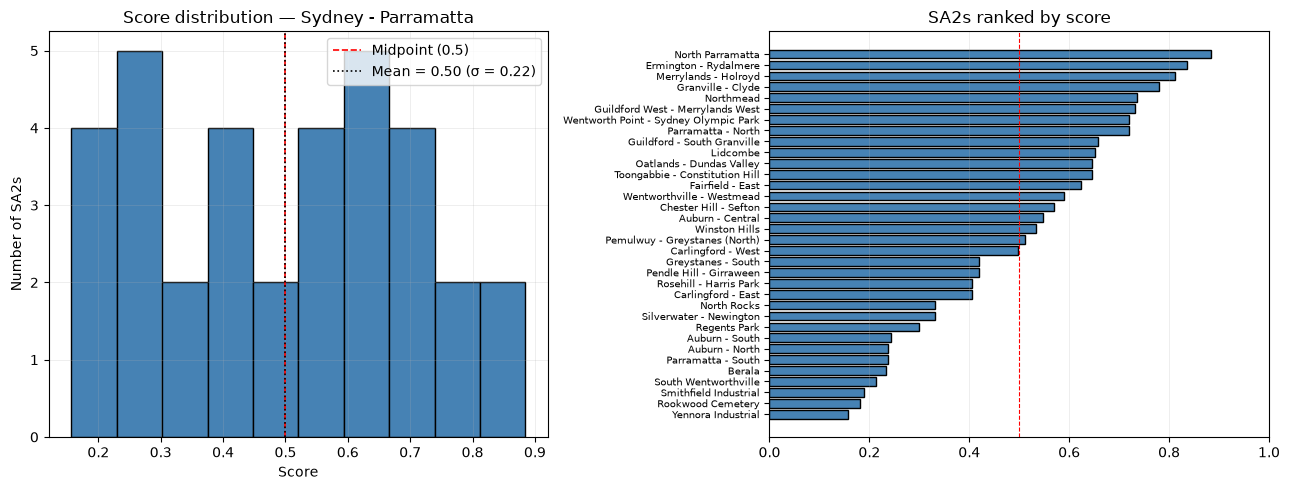

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram — score distribution within Sydney - Parramatta
axes[0].hist(poi_counts['score'], bins=10, color='steelblue', edgecolor='black')
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=1.2, label='Midpoint (0.5)')
axes[0].axvline(poi_counts['score'].mean(), color='black', linestyle=':', linewidth=1.2,
                label=f"Mean = {poi_counts['score'].mean():.2f} (σ = {poi_counts['score'].std():.2f})")
axes[0].set_title(f"Score distribution — Sydney - Parramatta")
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Number of SA2s')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Ranked bar chart
sorted_r = poi_counts.sort_values('score')
axes[1].barh(sorted_r['sa2_name'], sorted_r['score'], color='steelblue', edgecolor='black')
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=0.8)
axes[1].set_title('SA2s ranked by score'); axes[1].set_xlim(0, 1)
axes[1].tick_params(axis='y', labelsize=7); axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('parramatta_score_distribution.png', dpi=200, bbox_inches='tight')
plt.show()


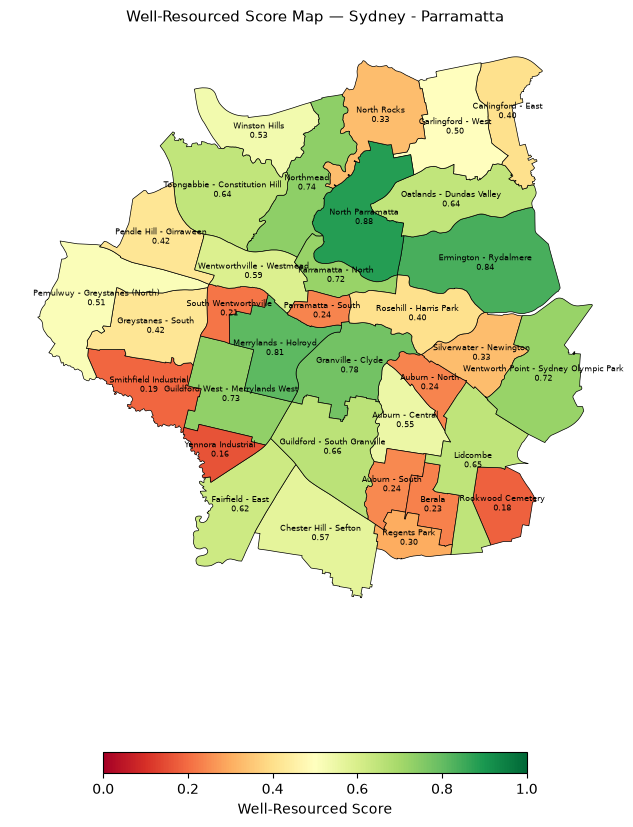

In [11]:
# Map overlay — choropleth of scores on SA2 polygons
scored = parra.merge(poi_counts, left_on='sa2_code_2021', right_on='sa2_code', how='left')

fig, ax = plt.subplots(figsize=(8, 9))
scored.plot(
    column='score', cmap='RdYlGn', vmin=0, vmax=1,
    edgecolor='black', linewidth=0.5,
    legend=True, ax=ax,
    legend_kwds={'label': 'Well-Resourced Score', 'shrink': 0.55, 'orientation': 'horizontal'}
)
for _, row in scored.iterrows():
    if pd.isna(row['score']): continue
    c = row.geometry.centroid
    ax.annotate(f"{row['sa2_name_2021']}\n{row['score']:.2f}",
                xy=(c.x, c.y), ha='center', va='center', fontsize=5.5)
ax.set_title("Well-Resourced Score Map — Sydney - Parramatta", fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.savefig('parramatta_score_map.png', dpi=200, bbox_inches='tight')
plt.show()


**Where do lower-scoring SA2s reside?** Lower-scoring SA2s concentrate in the southern industrial belt (Yennora Industrial 0.16, Smithfield Industrial 0.19) plus the Rookwood Cemetery (0.18) — designated non-residential land use rather than under-served residential areas.